# 06 · Differentiation of data: identifying a cooling law

**Problem.** A hot forging cools in still air. A data logger records its temperature, fast at first
and slower later (uneven time steps). Newton's law of cooling assumes
$dT/dt = -C\,(T - T_\infty)$, but natural convection suggests $h \propto \Delta T^{1/4}$, i.e.
$$\frac{dT}{dt} = -C\,(T - T_\infty)^{n},\qquad n = 1.25 .$$
Which is right? The **differential method**: estimate $dT/dt$ from the data, then fit
$\ln(-dT/dt) = \ln C + n\ln(T - T_\infty)$ - a straight line whose slope is $n$.

**What you will learn**

- differentiate unevenly spaced data to second-order accuracy
- derive a finite-difference formula from an interpolating parabola
- estimate a rate-law exponent by the differential method
- quantify how differentiation amplifies measurement noise

**Before you start:** notebook 00; Taylor series; a straight-line fit (explained fully in notebook 08)  ·  **Time:** about 45 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import differentiate, fitting

The data are generated from the exact solution of the $n = 1.25$ model,
$\Delta T(t) = \left[\Delta T_0^{-1/4} + C t/4\right]^{-4}$, so we know the right answer.

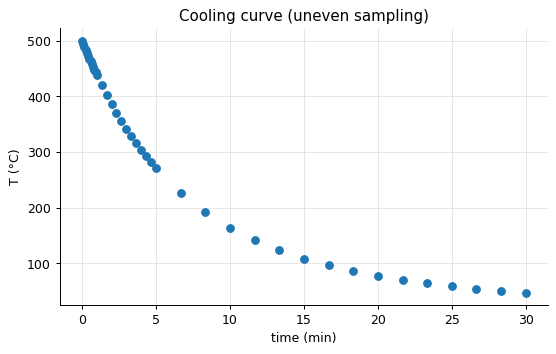

In [2]:
T_inf, dT0, C, n_true = 20.0, 480.0, 5.0e-4, 1.25
t = np.r_[np.arange(0, 60, 5), np.arange(60, 300, 20), np.arange(300, 1801, 100)].astype(float)   # s, uneven
dT = (dT0**-0.25 + C*t/4)**-4
T = T_inf + dT
plt.plot(t/60, T, "o"); plt.xlabel("time (min)"); plt.ylabel("T (°C)"); plt.title("Cooling curve (uneven sampling)")
plt.show()

## Derivatives on an uneven grid
Standard formulas assume equal spacing. `engmath.differentiate.gradient` uses 3-point Lagrange
formulas valid for **any** spacing (second-order accurate, exact for quadratics).

max relative error of the numerical derivative: 1.13 %
estimated exponent n = 1.248  (95 % CI 1.247 to 1.250; true 1.25)


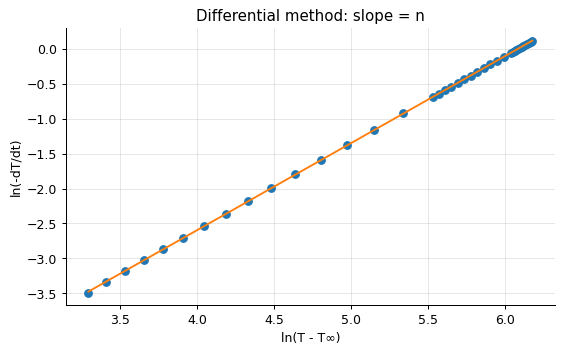

In [3]:
dTdt = differentiate.gradient(t, T)
exact = -C*dT**n_true
print(f"max relative error of the numerical derivative: {np.max(np.abs(dTdt/exact - 1))*100:.2f} %")
fit = fitting.linear_lstsq(np.column_stack([np.ones(t.size), np.log(dT)]), np.log(-dTdt))
lo, hi = fit.conf_int()[1]
print(f"estimated exponent n = {fit.coef[1]:.3f}  (95 % CI {lo:.3f} to {hi:.3f}; true 1.25)")
plt.plot(np.log(dT), np.log(-dTdt), "o"); plt.plot(np.log(dT), fit.coef[0] + fit.coef[1]*np.log(dT))
plt.xlabel("ln(T - T∞)"); plt.ylabel("ln(-dT/dt)"); plt.title("Differential method: slope = n"); plt.show()

## Inside the algorithm: derivatives on an uneven grid
Fit a parabola through three neighbouring points with spacings $h_1 = t_i - t_{i-1}$ and
$h_2 = t_{i+1} - t_i$, and differentiate it at $t_i$:
$$T'(t_i) \approx -\frac{h_2}{h_1(h_1+h_2)}T_{i-1} + \frac{h_2 - h_1}{h_1 h_2}T_i + \frac{h_1}{h_2(h_1+h_2)}T_{i+1}.$$
For equal spacing ($h_1 = h_2 = h$) this reduces to the familiar central difference $(T_{i+1} - T_{i-1})/2h$.

In [4]:
def interior_derivative(t, T):
    d = np.full(len(t), np.nan)
    for i in range(1, len(t) - 1):
        h1, h2 = t[i] - t[i-1], t[i+1] - t[i]
        d[i] = (-h2 / (h1 * (h1 + h2)) * T[i-1] + (h2 - h1) / (h1 * h2) * T[i]
                + h1 / (h2 * (h1 + h2)) * T[i+1])
    return d

print("max difference from the library at interior points:", np.nanmax(np.abs(interior_derivative(t, T) - dTdt)))

max difference from the library at interior points: 0.0


Newton's law ($n = 1$) is clearly rejected for this data set.

## The catch: differentiation amplifies noise
Add a realistic ±0.5 °C thermocouple noise and repeat:

temperature noise: 0.16 % of T;  derivative errors: median 2.1 %, max 75 %
noisy data: n = 1.249 ± 0.019   (noise-free: ± 0.001)


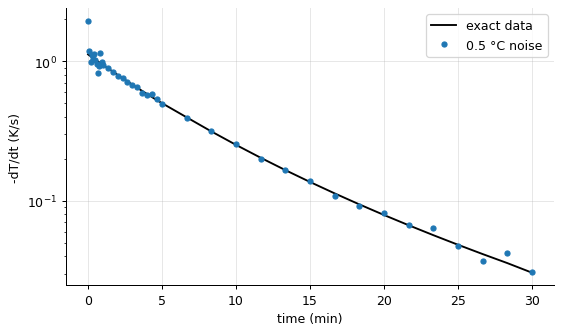

In [5]:
rng = np.random.default_rng(3)
T_noisy = T + rng.normal(0, 0.5, T.size)
d_noisy = differentiate.gradient(t, T_noisy)
ok = (d_noisy < 0) & (T_noisy > T_inf)             # logarithms need positive arguments
fit_n = fitting.linear_lstsq(np.column_stack([np.ones(ok.sum()), np.log(T_noisy[ok]-T_inf)]), np.log(-d_noisy[ok]))
rel = np.abs(d_noisy/exact - 1)
print(f"temperature noise: {100*0.5/np.median(T):.2f} % of T;  derivative errors: median {100*np.median(rel):.1f} %, max {100*rel.max():.0f} %")
print(f"noisy data: n = {fit_n.coef[1]:.3f} ± {fit_n.se[1]:.3f}   (noise-free: ± {fit.se[1]:.3f})")
plt.plot(t/60, -dTdt, "k-", label="exact data")
plt.plot(t/60, -d_noisy, "o", ms=4, label="0.5 °C noise")
plt.yscale("log"); plt.xlabel("time (min)"); plt.ylabel("-dT/dt (K/s)"); plt.legend(); plt.show()

Noise of a fraction of a percent in temperature becomes errors of tens of percent in individual
derivatives - worst at late times, where $T$ barely changes between readings. The estimate of $n$
survives here because many points average out, but its uncertainty grows about fifteen-fold, and
with fewer points or more noise the method fails outright. Two cures: **smooth before differentiating** (notebook 07) or **avoid
differentiation altogether** by fitting the integrated model directly (notebook 09).

## Exercises
1. Refit using only the first 10 minutes of data. How does the confidence interval of $n$ change?
2. Use `differentiate.forward` differences instead (first order). How large is the bias in $n$
   for the noise-free data?
3. Estimate $n$ from the noisy data by smoothing first with `engmath.smoothing.lowess`. Does the
   estimate improve?
4. **Implement it yourself:** using the same parabola, derive the one-sided formula for the *first* point (differentiate at $t_0$ instead of $t_1$). Implement it and check it against `differentiate.gradient` at $t = 0$.